# Training curves from `.qlog` files

Parses every `logs/train_*.qlog` run, selects the run with the lowest validation loss for each model architecture, stitches continuation runs to their preceding logs, and plots the full winning histories from epoch 1.

In [43]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

LOGS_DIR = Path("..") / "logs"

EPOCH_RE = re.compile(
    r"epoch\s+(\d+)\s*\|\s*"
    r"train loss\s+(nan|[\d.]+)\s+mae\s+(nan|[\d.]+)\s+r2\s+(nan|-?[\d.]+).*?\|\s*"
    r"val loss\s+(nan|[\d.]+)\s+mae\s+(nan|[\d.]+)\s+r2\s+(nan|-?[\d.]+)"
)
CONTINUATION_RE = re.compile(r"continuing from epoch\s+(\d+)")


def parse_qlog(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text().splitlines():
        match = EPOCH_RE.search(line)
        if not match:
            continue
        epoch, train_loss, train_mae, train_r2, val_loss, val_mae, val_r2 = match.groups()
        rows.append(
            {
                "epoch": int(epoch),
                "train_loss": float(train_loss),
                "train_mae": float(train_mae),
                "train_r2": float(train_r2),
                "val_loss": float(val_loss),
                "val_mae": float(val_mae),
                "val_r2": float(val_r2),
            }
        )
    return pd.DataFrame(rows)


def continuation_epoch(path: Path) -> int | None:
    match = CONTINUATION_RE.search(path.read_text())
    return int(match.group(1)) if match else None


def job_id(path: Path) -> int:
    return int(path.name.split(".")[-2])


def stitch_history(path: Path, model_runs) -> tuple[pd.DataFrame, list[Path]]:
    """Recursively prepend the log whose final epoch a run resumed from."""
    df = next(df for candidate, df in model_runs if candidate == path)
    resume_epoch = continuation_epoch(path)
    if resume_epoch is None:
        return df, [path]

    predecessors = [
        (candidate, candidate_df)
        for candidate, candidate_df in model_runs
        if candidate != path
        and job_id(candidate) < job_id(path)
        and int(candidate_df["epoch"].max()) == resume_epoch
    ]
    if not predecessors:
        print(f"warning: no log ending at epoch {resume_epoch} found before {path.name}")
        return df, [path]

    predecessor, _ = max(predecessors, key=lambda run: job_id(run[0]))
    earlier_df, earlier_paths = stitch_history(predecessor, model_runs)
    combined = pd.concat([earlier_df, df], ignore_index=True)
    combined = combined.drop_duplicates("epoch", keep="last").sort_values("epoch")
    return combined.reset_index(drop=True), [*earlier_paths, path]

In [44]:
qlog_paths = sorted(
    path
    for path in LOGS_DIR.glob("train_*.qlog")
    if not path.name.split(".")[0].endswith("_fixed")
)

candidates = {}
for path in qlog_paths:
    model_name = path.name.split(".")[0].removeprefix("train_")
    df = parse_qlog(path)
    if df.empty:
        print(f"no epoch lines found in {path.name}, skipping")
        continue
    candidates.setdefault(model_name, []).append((path, df))

runs = {}
selected_paths = {}
for model_name, model_runs in sorted(candidates.items()):
    path, selected_df = min(model_runs, key=lambda run: run[1]["val_loss"].min())
    df, history_paths = stitch_history(path, model_runs)
    runs[model_name] = df
    selected_paths[model_name] = history_paths
    best = df.loc[df["val_loss"].idxmin()]
    print(
        f"{model_name}: selected {' -> '.join(p.name for p in history_paths)} "
        f"from {len(model_runs)} run(s); "
        f"best val loss {best['val_loss']:.4f} at epoch {int(best['epoch'])}"
    )

CNN: selected train_CNN.6876565.qlog -> train_CNN.6878896.qlog from 6 run(s); best val loss 0.0181 at epoch 54
CNN_LSTM: selected train_CNN_LSTM.6876566.qlog -> train_CNN_LSTM.6878910.qlog from 4 run(s); best val loss 0.0191 at epoch 65
LSTM: selected train_LSTM.6874798.qlog from 4 run(s); best val loss 0.0205 at epoch 42
ResNet: selected train_ResNet.6873851.qlog from 3 run(s); best val loss 0.0194 at epoch 21
ViT: selected train_ViT.6878663.qlog from 4 run(s); best val loss 0.0203 at epoch 10


## Train vs. val loss per model

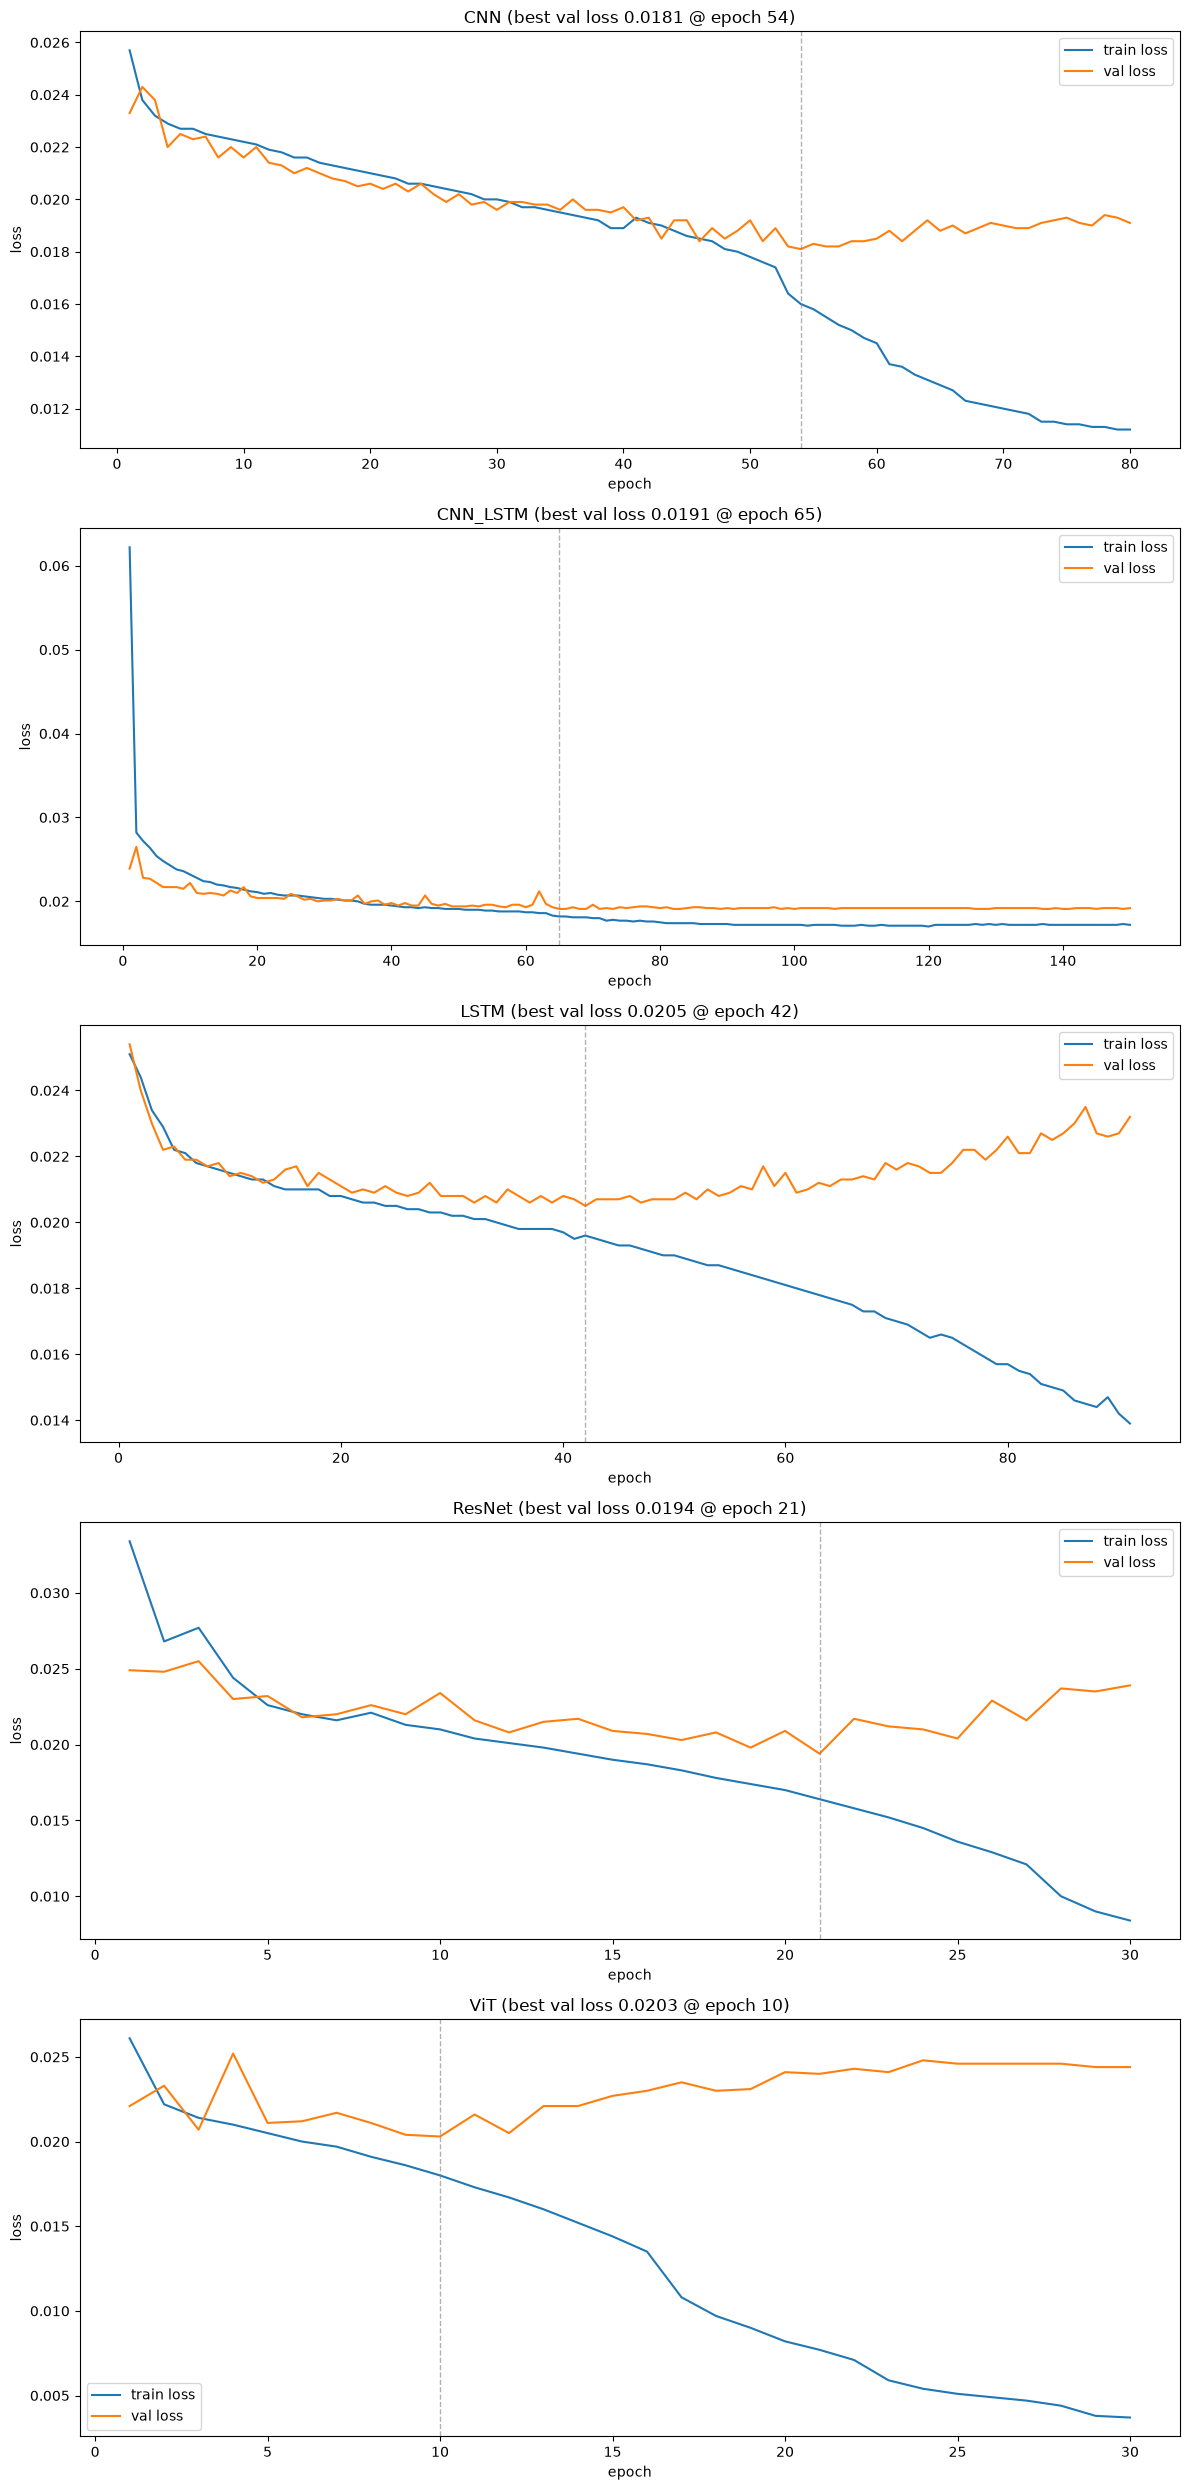

In [45]:
fig, axes = plt.subplots(len(runs), 1, figsize=(12, 5 * len(runs)), squeeze=False)

for ax, (model_name, df) in zip(axes[:, 0], runs.items()):
    ax.plot(df["epoch"], df["train_loss"], label="train loss")
    ax.plot(df["epoch"], df["val_loss"], label="val loss")
    best_epoch = df.loc[df["val_loss"].idxmin()]
    ax.axvline(best_epoch["epoch"], color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(f"{model_name} (best val loss {best_epoch['val_loss']:.4f} @ epoch {int(best_epoch['epoch'])})")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()

fig.tight_layout()
plt.show()

## Val loss comparison across models

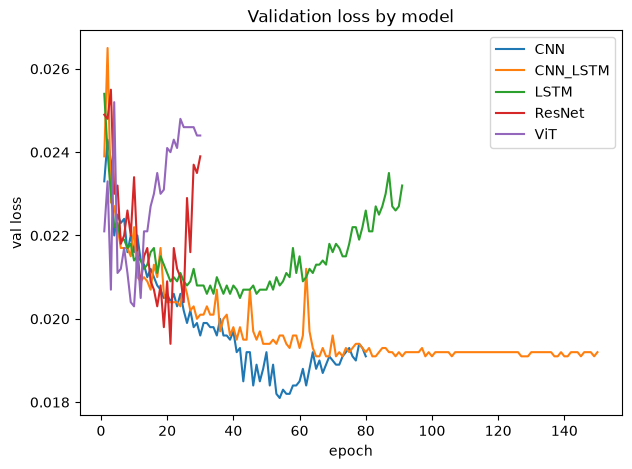

In [46]:
fig, ax = plt.subplots(figsize=(7, 5))

for model_name, df in runs.items():
    ax.plot(df["epoch"], df["val_loss"], label=model_name)

ax.set_xlabel("epoch")
ax.set_ylabel("val loss")
ax.set_title("Validation loss by model")
ax.legend()
plt.show()

# Fixed-model training curves

Parses only `logs/train_*_fixed.*.qlog` runs and plots the fixed architectures separately.

In [47]:
fixed_qlog_paths = sorted(LOGS_DIR.glob("train_*_fixed.*.qlog"))
if not fixed_qlog_paths:
    raise FileNotFoundError(f"no fixed-model qlogs found in {LOGS_DIR.resolve()}")

fixed_candidates = {}
for path in fixed_qlog_paths:
    model_name = path.name.split(".")[0].removeprefix("train_").removesuffix("_fixed")
    df = parse_qlog(path)
    if df.empty:
        print(f"no epoch lines found in {path.name}, skipping")
        continue
    fixed_candidates.setdefault(model_name, []).append((path, df))

fixed_runs = {}
fixed_selected_paths = {}
for model_name, model_runs in sorted(fixed_candidates.items()):
    path, selected_df = min(model_runs, key=lambda run: run[1]["val_loss"].min())
    df, history_paths = stitch_history(path, model_runs)
    fixed_runs[model_name] = df
    fixed_selected_paths[model_name] = history_paths
    best = df.loc[df["val_loss"].idxmin()]
    print(
        f"{model_name}: selected {' -> '.join(p.name for p in history_paths)} "
        f"from {len(model_runs)} fixed run(s); "
        f"best val loss {best['val_loss']:.4f} at epoch {int(best['epoch'])}"
    )

CNN: selected train_CNN_fixed.6925285.qlog from 1 fixed run(s); best val loss 0.0207 at epoch 29
CNN_LSTM: selected train_CNN_LSTM_fixed.6925286.qlog from 1 fixed run(s); best val loss 0.0206 at epoch 9
LSTM: selected train_LSTM_fixed.6925287.qlog from 1 fixed run(s); best val loss 0.0221 at epoch 7
ResNet: selected train_ResNet_fixed.6929601.qlog from 1 fixed run(s); best val loss 0.0210 at epoch 16
ViT: selected train_ViT_fixed.6929599.qlog from 1 fixed run(s); best val loss 0.0197 at epoch 7


## Fixed train vs. val loss per model

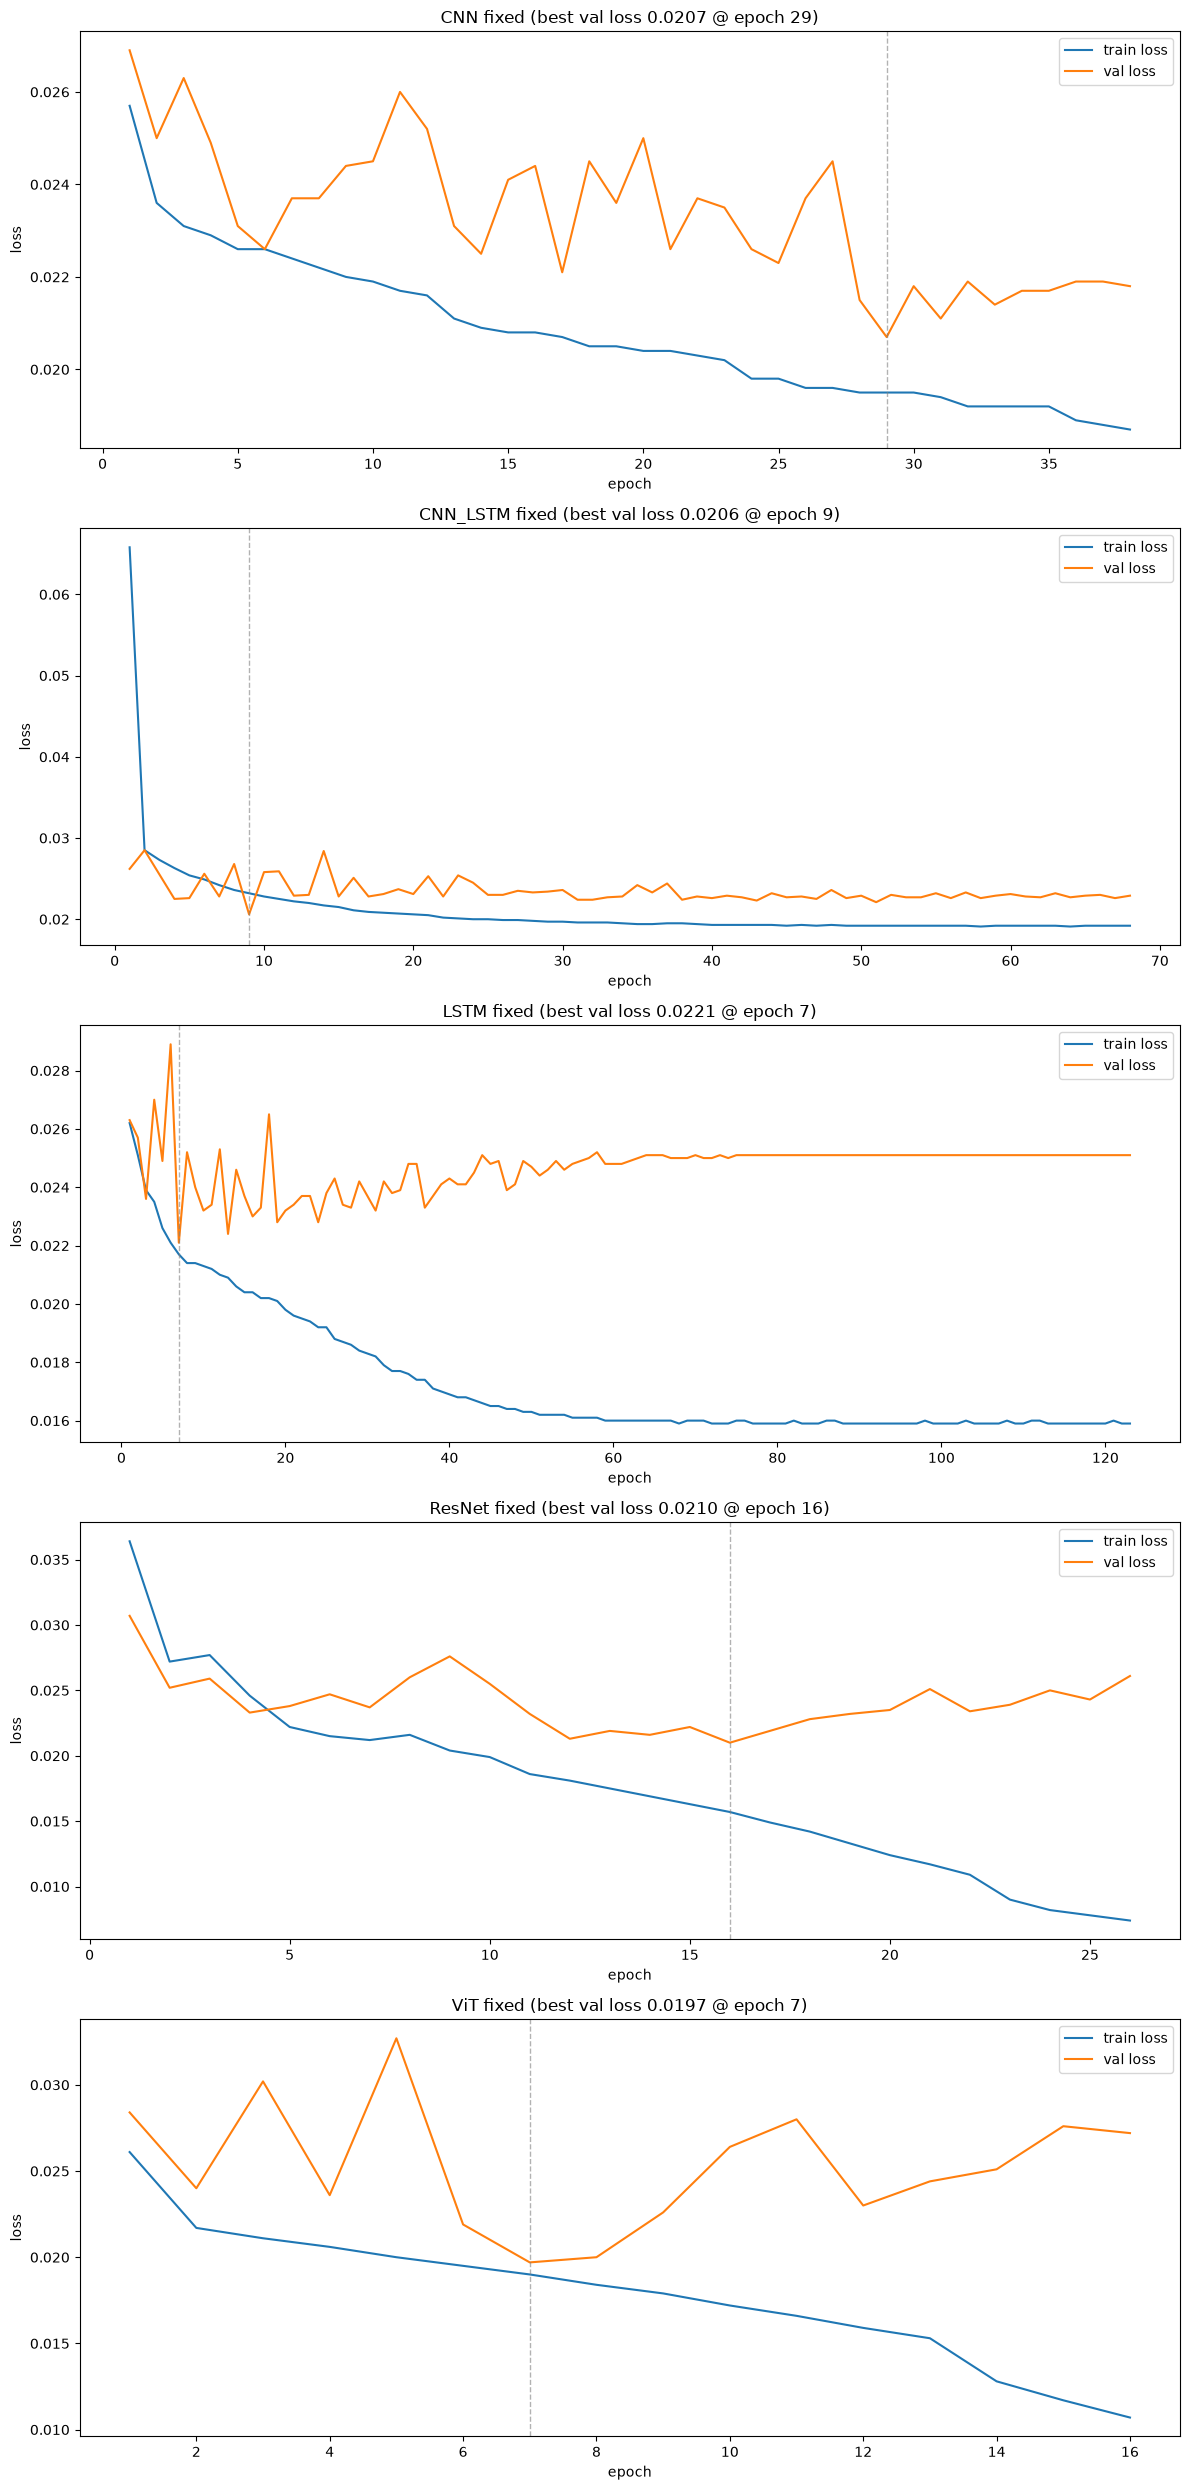

In [48]:
fig, axes = plt.subplots(len(fixed_runs), 1, figsize=(12, 5 * len(fixed_runs)), squeeze=False)

for ax, (model_name, df) in zip(axes[:, 0], fixed_runs.items()):
    ax.plot(df["epoch"], df["train_loss"], label="train loss")
    ax.plot(df["epoch"], df["val_loss"], label="val loss")
    best_epoch = df.loc[df["val_loss"].idxmin()]
    ax.axvline(best_epoch["epoch"], color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(f"{model_name} fixed (best val loss {best_epoch['val_loss']:.4f} @ epoch {int(best_epoch['epoch'])})")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()

fig.tight_layout()
plt.show()

## Fixed val loss comparison across models

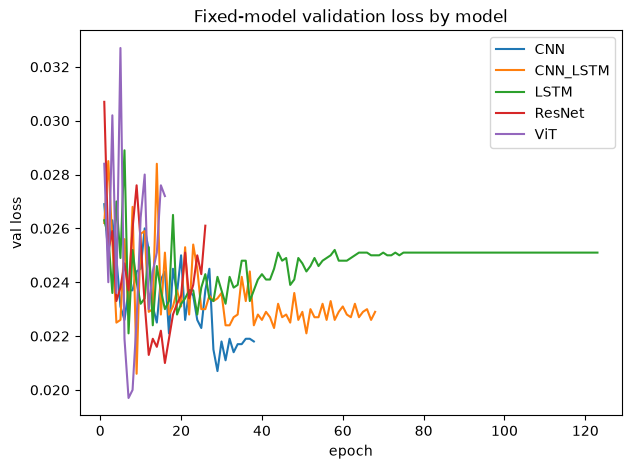

In [49]:
fig, ax = plt.subplots(figsize=(7, 5))

for model_name, df in fixed_runs.items():
    ax.plot(df["epoch"], df["val_loss"], label=model_name)

ax.set_xlabel("epoch")
ax.set_ylabel("val loss")
ax.set_title("Fixed-model validation loss by model")
ax.legend()
plt.show()